## EDA

In [38]:
import pandas as pd

df = pd.read_csv('retail_sales_dataset.csv')
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [39]:
# Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [40]:
# Descriptive Statistics
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [41]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Unique values in categorical columns
print("\nUnique values in Gender:", df['Gender'].unique())
print("Unique values in Product Category:", df['Product Category'].unique())

# Check if Total Amount = Quantity * Price per Unit
df['Calculated Total'] = df['Quantity'] * df['Price per Unit']
inconsistencies = (df['Total Amount'] != df['Calculated Total']).sum()
print(f"\nNumber of inconsistencies in Total Amount: {inconsistencies}")

Number of duplicate rows: 0

Unique values in Gender: ['Male' 'Female']
Unique values in Product Category: ['Beauty' 'Clothing' 'Electronics']

Number of inconsistencies in Total Amount: 0


In [42]:
# Check date range
df['Date'] = pd.to_datetime(df['Date'])
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Check for any invalid dates or future dates
current_date = pd.Timestamp.now()
future_dates = df[df['Date'] > current_date]
print(f"Number of future dates: {len(future_dates)}")

# Age distribution
print(f"Age range: {df['Age'].min()} to {df['Age'].max()}")

Date range: 2023-01-01 00:00:00 to 2024-01-01 00:00:00
Number of future dates: 0
Age range: 18 to 64


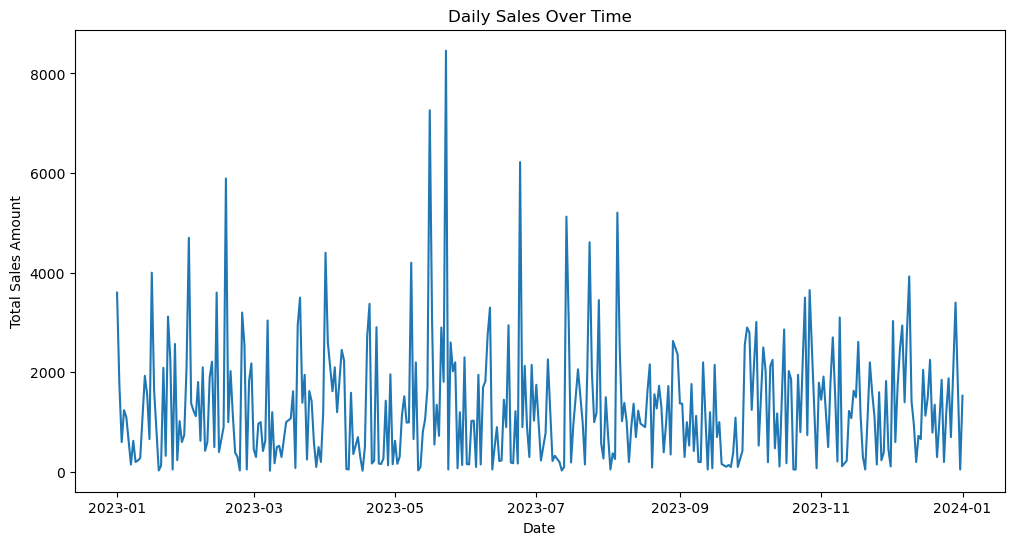

In [43]:
# Time Series Analysis
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate daily sales
daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()
daily_sales.set_index('Date', inplace=True)

# Plot daily sales
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales['Total Amount'])
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.show()

C:\Users\silve\AppData\Local\Temp\ipykernel_9300\4249032063.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales.resample('M')['Total Amount'].sum()


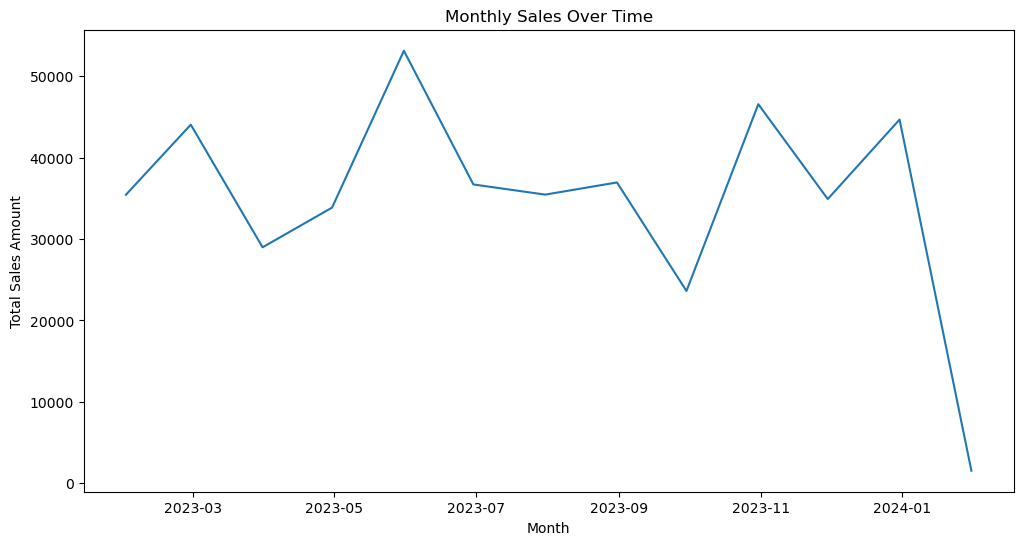

In [44]:
# Monthly sales
monthly_sales = daily_sales.resample('M')['Total Amount'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.show()

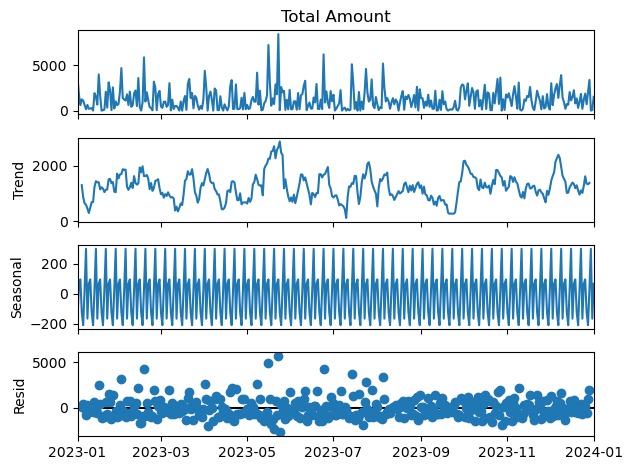

In [45]:
# Seasonal Decomposition (Weekly pattern)
daily_sales = daily_sales.asfreq('D').fillna(0)

decomposition = seasonal_decompose(daily_sales['Total Amount'], model='additive', period=7)
decomposition.plot()
plt.show()

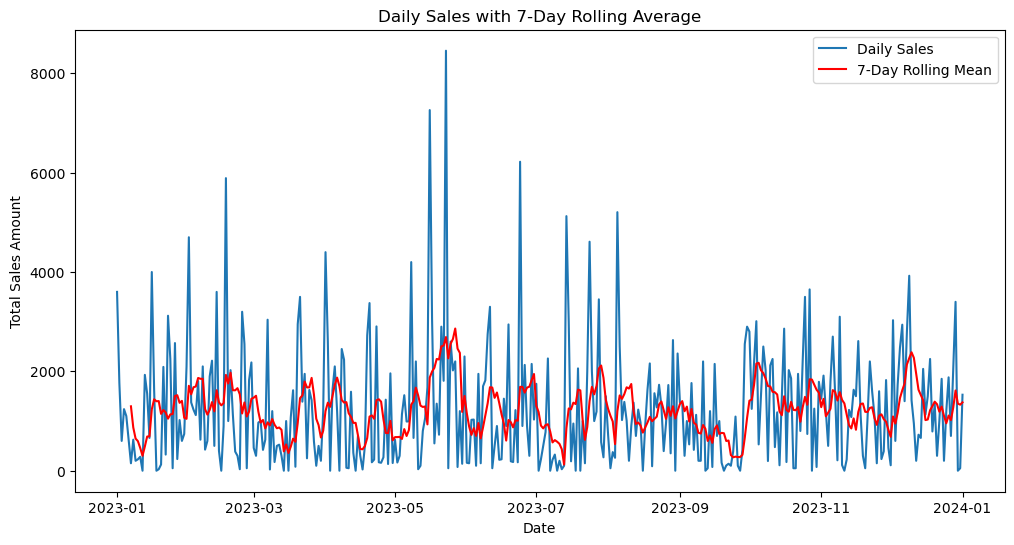

In [46]:
# Rolling average (7-day for daily sales)
daily_sales['Rolling Mean'] = daily_sales['Total Amount'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales['Total Amount'], label='Daily Sales')
plt.plot(daily_sales.index, daily_sales['Rolling Mean'], label='7-Day Rolling Mean', color='red')
plt.title('Daily Sales with 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.legend()
plt.show()

In [47]:
# Monthly sales summary
print("Monthly Sales Totals:")
print(monthly_sales)

Monthly Sales Totals:
Date
2023-01-31    35450
2023-02-28    44060
2023-03-31    28990
2023-04-30    33870
2023-05-31    53150
2023-06-30    36715
2023-07-31    35465
2023-08-31    36960
2023-09-30    23620
2023-10-31    46580
2023-11-30    34920
2023-12-31    44690
2024-01-31     1530
Freq: ME, Name: Total Amount, dtype: int64


## Customer Demographics and Purchasing Behavior
This section examines customer age and gender profiles, product preferences, and how purchasing behavior varies across customer segments.

Gender distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64

Age distribution:
count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64

Age groups:
Age
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
Name: count, dtype: int64

Product category distribution:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

Average total amount by gender:
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

Average total amount by product category:
Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64

Top 10 customers by total spend:
             transactions  total_spend  avg_order
Customer ID                                      
CUST487                 1         2000     2000.0

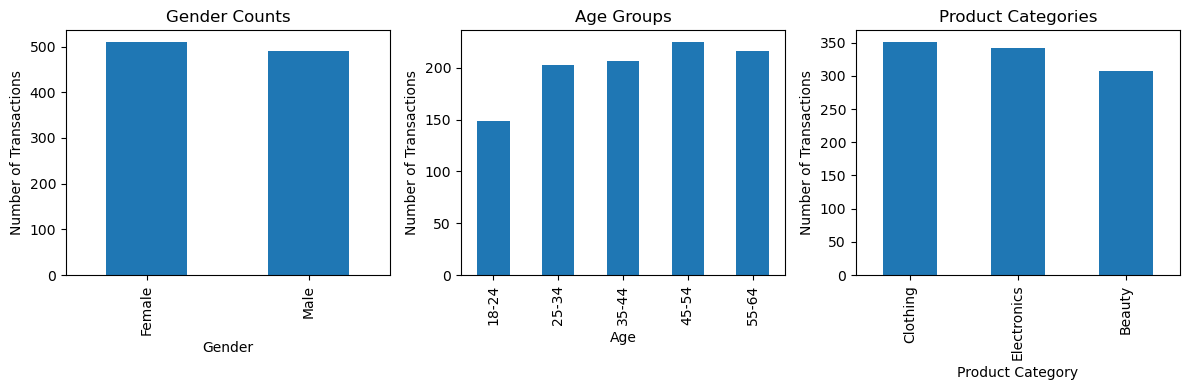

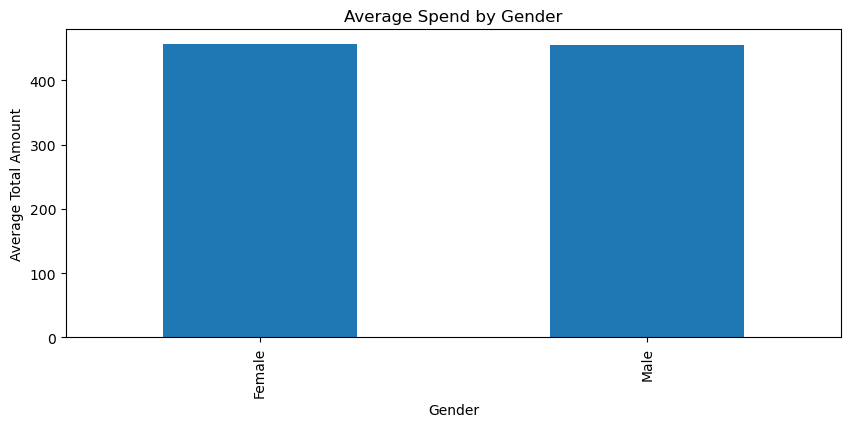

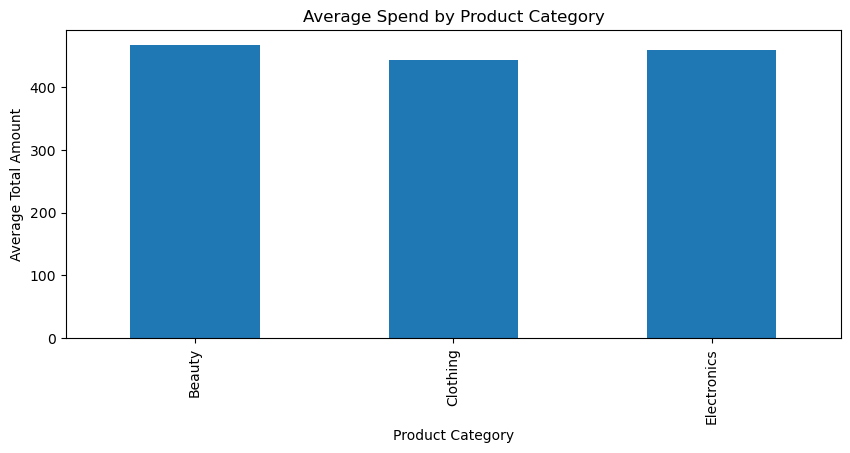

In [48]:
# Customer demographics and purchasing behavior
import matplotlib.pyplot as plt

# Gender distribution
gender_counts = df['Gender'].value_counts()
print('Gender distribution:')
print(gender_counts)

# Age distribution and groups
age_stats = df['Age'].describe()
age_bins = pd.cut(df['Age'], bins=[17, 24, 34, 44, 54, 64], labels=['18-24', '25-34', '35-44', '45-54', '55-64'])
age_group_counts = age_bins.value_counts().sort_index()
print('\nAge distribution:')
print(age_stats)
print('\nAge groups:')
print(age_group_counts)

# Product category preferences
category_counts = df['Product Category'].value_counts()
print('\nProduct category distribution:')
print(category_counts)

# Average spend by gender and category
avg_spend_gender = df.groupby('Gender')['Total Amount'].mean()
avg_spend_category = df.groupby('Product Category')['Total Amount'].mean()
print('\nAverage total amount by gender:')
print(avg_spend_gender)
print('\nAverage total amount by product category:')
print(avg_spend_category)

# Customer-level behavior
customer_summary = df.groupby('Customer ID').agg(
    transactions=('Transaction ID', 'count'),
    total_spend=('Total Amount', 'sum'),
    avg_order=('Total Amount', 'mean')
).sort_values('total_spend', ascending=False)
print('\nTop 10 customers by total spend:')
print(customer_summary.head(10))

# Visualizations
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
gender_counts.plot(kind='bar', title='Gender Counts')
plt.ylabel('Number of Transactions')

plt.subplot(1, 3, 2)
age_group_counts.plot(kind='bar', title='Age Groups')
plt.ylabel('Number of Transactions')

plt.subplot(1, 3, 3)
category_counts.plot(kind='bar', title='Product Categories')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
avg_spend_gender.plot(kind='bar', title='Average Spend by Gender')
plt.ylabel('Average Total Amount')
plt.show()

plt.figure(figsize=(10, 4))
avg_spend_category.plot(kind='bar', title='Average Spend by Product Category')
plt.ylabel('Average Total Amount')
plt.show()

C:\Users\silve\AppData\Local\Temp\ipykernel_9300\3341059249.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_gender = df.groupby([pd.Grouper(key='Date', freq='M'), 'Gender'])['Total Amount'].sum().unstack()


<Figure size 1000x500 with 0 Axes>

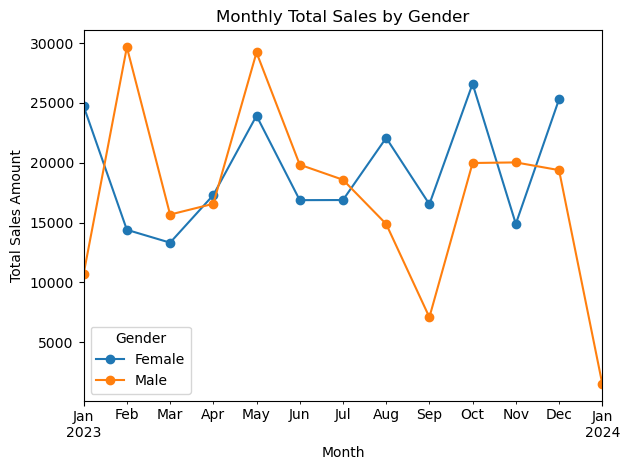

C:\Users\silve\AppData\Local\Temp\ipykernel_9300\3341059249.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spend_category.index, y=avg_spend_category.values, palette='viridis')


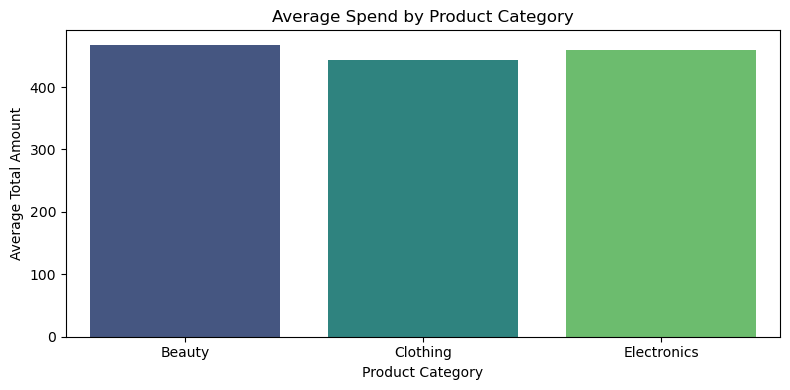

C:\Users\silve\AppData\Local\Temp\ipykernel_9300\3341059249.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='magma')


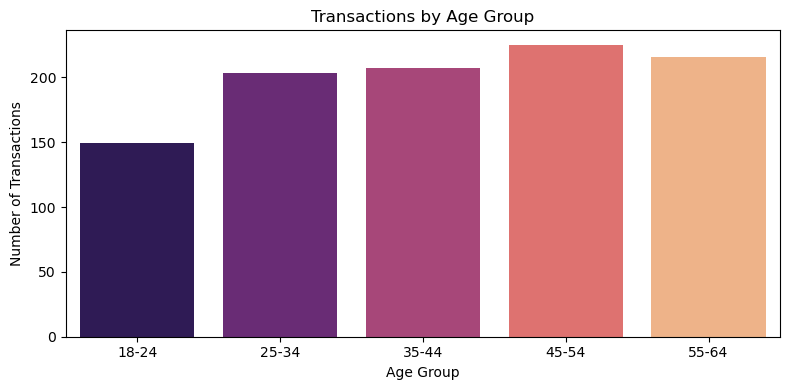

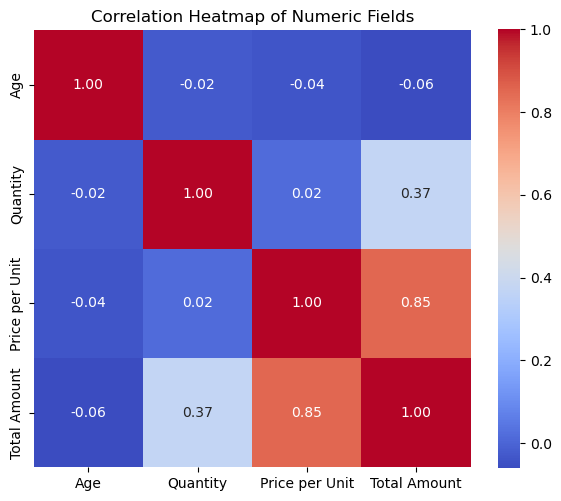

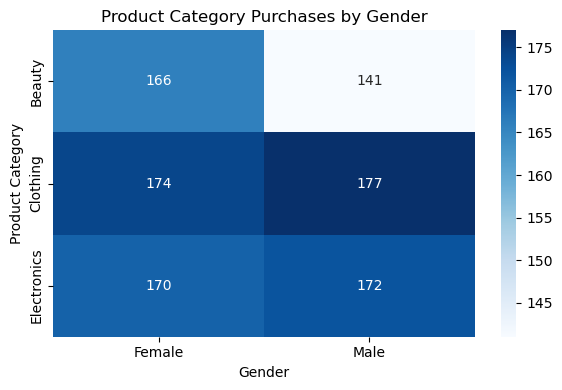

In [49]:
# Visual insights: bar charts, line plots, and heatmaps
import seaborn as sns

# Monthly sales by gender
monthly_gender = df.groupby([pd.Grouper(key='Date', freq='M'), 'Gender'])['Total Amount'].sum().unstack()

plt.figure(figsize=(10, 5))
monthly_gender.plot(marker='o')
plt.title('Monthly Total Sales by Gender')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Bar chart: average spend by product category
plt.figure(figsize=(8, 4))
sns.barplot(x=avg_spend_category.index, y=avg_spend_category.values, palette='viridis')
plt.title('Average Spend by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

# Bar chart: age group purchase counts
plt.figure(figsize=(8, 4))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='magma')
plt.title('Transactions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

# Heatmap: numerical correlation
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numeric Fields')
plt.tight_layout()
plt.show()

# Heatmap: product category counts by gender
category_gender = pd.crosstab(df['Product Category'], df['Gender'])
plt.figure(figsize=(6, 4))
sns.heatmap(category_gender, annot=True, fmt='d', cmap='Blues')
plt.title('Product Category Purchases by Gender')
plt.xlabel('Gender')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()